# VM-UNet — Liver & Tumor Segmentation

**Cấu trúc project:**
```
configs/config.py       ← Tất cả hyperparameter ở đây
data/dataset.py         ← DataBlock, splitter patient-level
models/vmunet/          ← VMUNet V2, VSSM, CBAM, SDI
utils/losses.py         ← DeepSupervisionLoss (CE + Dice)
utils/metrics.py        ← foreground_acc, DSAwareDiceMulti
utils/checkpoint.py     ← Load pretrained VMamba weights
utils/visualize.py      ← Visualization helpers
scripts/build_model.py  ← Factory tạo model từ config
scripts/train.py        ← Pipeline train đầy đủ
scripts/predict.py      ← Inference loop
```

---
## Cell 0 — Kiểm tra môi trường

In [33]:
import sys, torch

print(f'Python  : {sys.executable}')
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f'GPU     : {props.name}  ({props.total_memory/1e9:.1f} GB VRAM)')

try:
    import fastai
    print(f'fastai  : {fastai.__version__}')
except ImportError:
    print('fastai  : NOT FOUND — pip install fastai')

Python  : /venv/main/bin/python
PyTorch : 2.11.0+cu128
CUDA    : True
GPU     : NVIDIA GeForce RTX 3070  (8.2 GB VRAM)
fastai  : 2.8.7


---
## Cell 1 — Setup sys.path

In [34]:
import sys
from pathlib import Path

PROJECT_ROOT = Path('/workspace/files')

assert PROJECT_ROOT.exists(), f'Project root không tìm thấy: {PROJECT_ROOT}'
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'sys.path: {PROJECT_ROOT}')

sys.path: /workspace/files


---
## Cell 2 — Config
> **Chỉ cần sửa cell này để điều chỉnh toàn bộ experiment.**

In [35]:
from configs.config import Config, PathConfig, DataConfig, ModelConfig, TrainConfig
from pathlib import Path

cfg = Config(
    paths=PathConfig(
        data_dir           = Path('/workspace/files'),
        train_images       = Path('/workspace/files/dataset/train/images'),
        train_masks        = Path('/workspace/files/dataset/train/masks'),
        test_images        = Path('/workspace/files/dataset/test/images'),
        test_masks         = Path('/workspace/files/dataset/test/masks'),
        pretrained_weights = Path('/workspace/files/pre_trained_weights/vmamba_small_e238_ema.pth'),
        output_dir         = Path('/workspace/files/outputs'),
        model_name         = 'unet',
    ),
    data=DataConfig(
        image_size    = 256,
        batch_size    = 8,
        num_classes   = 3,             # background / liver / tumor
        class_names   = ['background', 'liver', 'tumor'],
        train_ratio   = 0.8,
        seed          = 42,
        num_workers   = 4,
        # Augmentation
        do_flip       = True,
        flip_vert     = True,
        max_rotate    = 10.0,
        max_zoom      = 1.05,
        max_lighting  = 0.02,
        max_warp      = 0.0,
    ),
    model=ModelConfig(
            depths         = [2, 2, 9, 2],
            depths_decoder = [2, 9, 2, 2],
            drop_path_rate = 0.2,
            use_checkpoint = False,             
            name           = 'unet',   # <-- ĐÃ SỬA: Đổi thành 'name'
        ),
    train=TrainConfig(
        num_epochs       = 10,
        learning_rate    = 1e-4,       
        weight_decay     = 0.01,
        mixed_precision  = 'bf16',     
        ds_weights       = [0.2, 0.3, 0.4, 1.0],  
        ce_weight        = 1.0,
        dice_weight      = 1.0,
        freeze_epochs    = 0,          
        save_best        = True,
        use_deep_supervision = False,       # <-- CHỖ NÀY: Tắt cơ chế rẽ nhánh Loss phụ
    ),
)

cfg.summary()

  VM-UNetV2 Engine  —  Config Summary
  Model Architecture: UNET
  Deep Supervision  : False
  Data Directory    : /workspace/files
  Image Input Size  : 256×256
  Batch Size        : 8
  Target Classes    : 3 ['background', 'liver', 'tumor']
  Total Epochs      : 10
  Initial LR        : 0.0001
  Mixed Precision   : bf16
  Output Directory  : /workspace/files/outputs


---
## Cell 3 — Dữ liệu

In [36]:
from data.dataset import build_dataloaders, verify_batch

db, dls, ds = build_dataloaders(cfg.data, cfg.paths)
print(f'Train batches: {len(dls.train)}  |  Valid batches: {len(dls.valid)}')

# Kiểm tra shape và giá trị hợp lệ
xb, yb = dls.one_batch()
print(f"Input  batch : {tuple(xb.shape)}  "
      f"dtype={xb.dtype}  min={xb.min().item():.2f}  max={xb.max().item():.2f}")

Train batches: 798  |  Valid batches: 211
Input  batch : (8, 1, 256, 256)  dtype=torch.float32  min=0.00  max=1.00


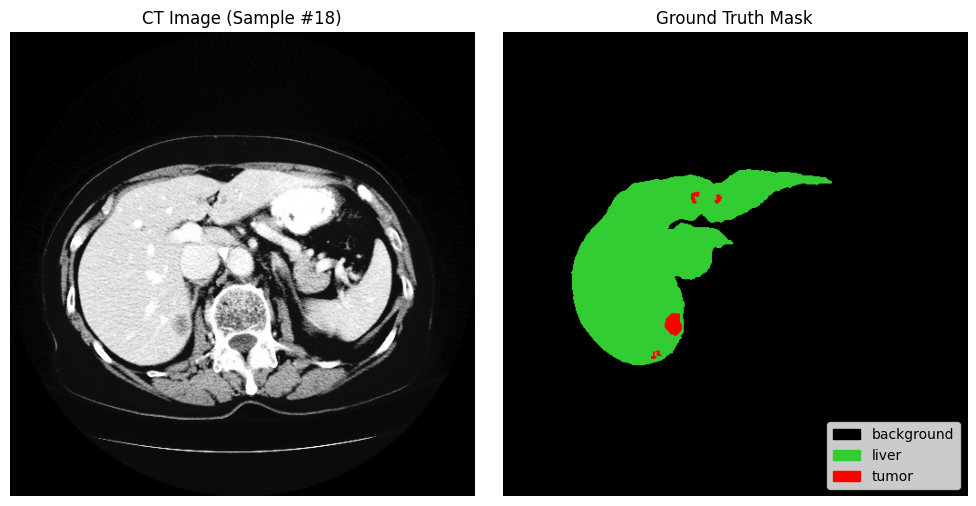

In [37]:
# Xem 1 sample cụ thể
from utils.visualize import show_sample

show_sample(ds, idx=18, data_cfg=cfg.data)

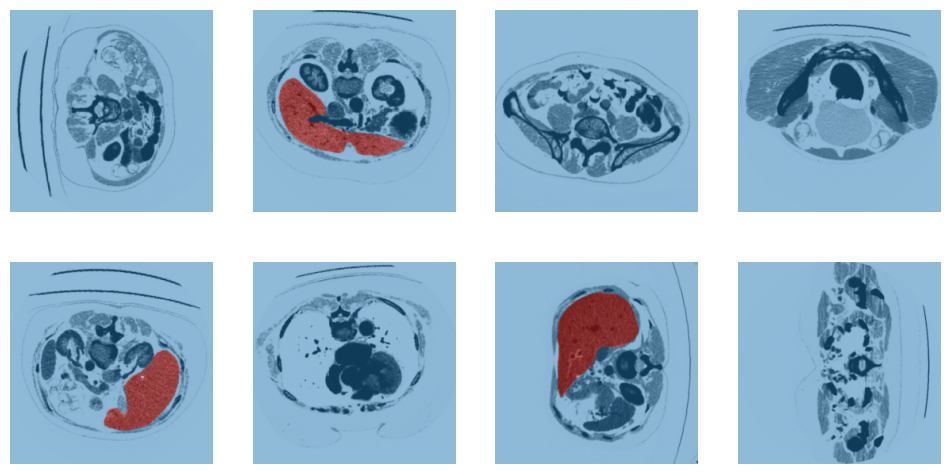

In [38]:
# Xem 1 batch ngẫu nhiên
dls.show_batch()

---
## Cell 4 — Build Model

In [39]:
from scripts.build_model import build_model

model = build_model(cfg, load_pretrained=True, verbose=True)

[Baseline] Initializing Standard U-Net...


In [40]:
import torch
from scripts.build_model import build_model

# 1. Khởi tạo model 1 kênh chuẩn theo config
model = build_model(cfg, load_pretrained=False, verbose=False).cuda()

# 2. Lấy động số kênh từ cấu hình (lúc này tự động bốc số 1)
in_channels = getattr(cfg.data, "input_channels", 1)
dummy = torch.randn(2, in_channels, 256, 256).cuda()  # <-- Đã đồng bộ thành 1 kênh

model.eval()
with torch.no_grad():
    out = model(dummy)
print(f'[EVAL]  output shape : {tuple(out.shape)}')   # Sẽ in ra: (2, 3, 256, 256)

model.train()

[EVAL]  output shape : (2, 3, 256, 256)


Unet(
  (encoder): VGGEncoder(
    (features): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=True)
      

---
## Cell 5 — (Optional) Tìm Learning Rate

In [41]:
# Bỏ comment block này để chạy lr_find
# from scripts.train import build_learner
#
# learn_tmp = build_learner(cfg, dls, model)
# result    = learn_tmp.lr_find(suggest_funcs=(valley,))
# print(f'\n💡 Suggested LR: {result.valley:.2e}')
#
# # Gán lr tìm được vào config
# cfg.train.learning_rate = result.valley
# del learn_tmp  # giải phóng bộ nhớ

---
## Cell 6 — Training

In [42]:
from scripts.train import build_learner
from fastai.callback.tracker import SaveModelCallback

learn = build_learner(cfg, dls, model)
print('Loss function :', learn.loss_func)
print('Metrics       :', [m.__name__ if hasattr(m, '__name__') else type(m).__name__
                          for m in learn.metrics])

Loss function : CombinedLoss(
  (dice): MultiClassDiceLoss()
)
Metrics       : ['AvgMetric', 'DSAwareDiceMulti']


In [43]:
# ── Optional: Freeze encoder N epoch đầu ─────────────────────────────────────
if cfg.train.freeze_epochs > 0:
    print(f'Freezing encoder for {cfg.train.freeze_epochs} epoch(s)...')
    learn.freeze()
    learn.fit_one_cycle(
        cfg.train.freeze_epochs,
        lr_max=cfg.train.learning_rate or 1e-3,
        wd=cfg.train.weight_decay,
    )
    learn.unfreeze()
    print('Bắt đầu training...')

In [12]:
# ── Fine-tune ─────────────────────────────────────────────────────────────────
cbs = []
if cfg.train.save_best:
    cbs.append(SaveModelCallback(
        monitor='valid_loss',
        fname=cfg.paths.best_model_path.name,
    ))

learn.fine_tune(
    cfg.train.num_epochs,
    base_lr=cfg.train.learning_rate or 1e-3,
    wd=cfg.train.weight_decay,
    cbs=cbs,
)

epoch,train_loss,valid_loss,cust_foreground_acc,ds_aware_dice_multi,time
0,0.681403,0.676323,0.989941,0.581461,01:23


Better model found at epoch 0 with valid_loss value: 0.6763229370117188.


epoch,train_loss,valid_loss,cust_foreground_acc,ds_aware_dice_multi,time
0,0.609936,0.621462,0.992779,0.610970,01:21
1,0.606800,0.606596,0.991632,0.609890,01:21
2,0.588895,0.620474,0.992347,0.698163,01:21
3,0.573230,0.616912,0.991322,0.745095,01:21
4,0.579281,0.588213,0.992044,0.718304,01:21
5,0.556500,0.564871,0.995270,0.848343,01:21
6,0.559886,0.579037,0.993808,0.758114,01:21
7,0.553390,0.577626,0.994165,0.816290,01:21
8,0.547361,0.576304,0.994423,0.828267,01:21
9,0.549434,0.575764,0.994455,0.827127,01:21


Better model found at epoch 0 with valid_loss value: 0.6214622855186462.
Better model found at epoch 1 with valid_loss value: 0.6065959930419922.
Better model found at epoch 4 with valid_loss value: 0.5882129073143005.
Better model found at epoch 5 with valid_loss value: 0.5648712515830994.


---
## Cell 7 — Kết quả & Export

<Axes: title={'center': 'learning curve'}, xlabel='steps', ylabel='loss'>

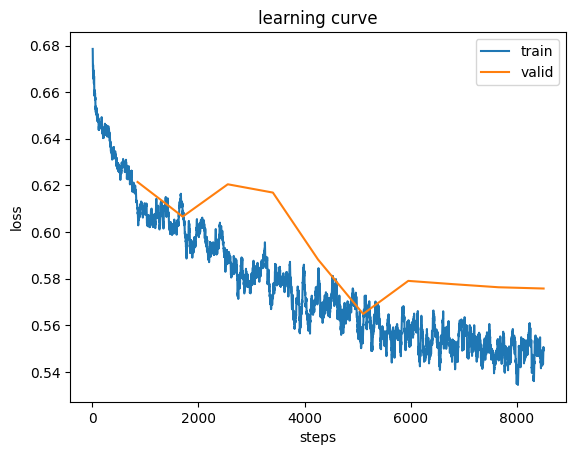

In [13]:
# Plot loss curve
learn.recorder.plot_loss()

In [14]:
# Export model
learn.export(cfg.paths.export_path)
print(f'✅ Model exported → {cfg.paths.export_path}')

✅ Model exported → /workspace/files/outputs/unet.pkl


---
## Cell 8 — Inference: Xem Prediction trên ảnh có Tumor

In [44]:
from utils.visualize import find_tumor_images, show_predictions

# Tìm ảnh có tumor
tumor_images = find_tumor_images(cfg.paths, tumor_class_idx=2)
print(f'Hiển thị 10/{len(tumor_images)} ảnh đầu...')

🔍 Tìm thấy 1049 ảnh có tumor.
Hiển thị 10/1049 ảnh đầu...


/venv/main/lib/python3.12/site-packages/fastai/metrics.py:375: RuntimeWarning: Mean of empty slice
  return np.nanmean(binary_dice_scores)


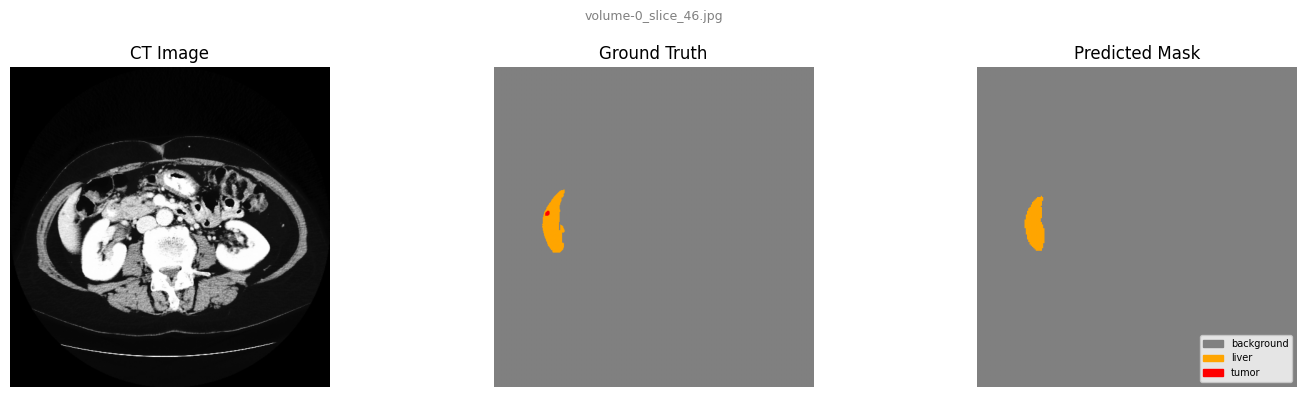

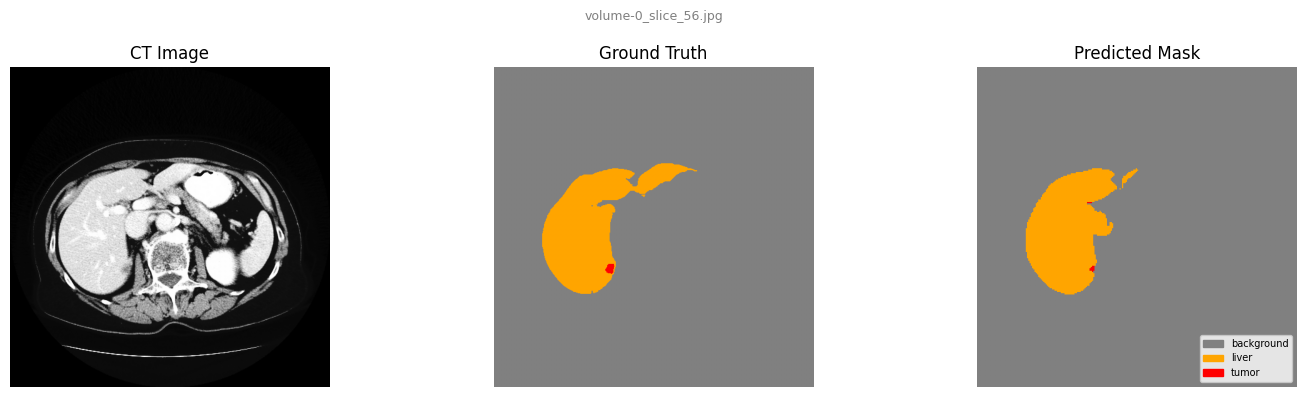

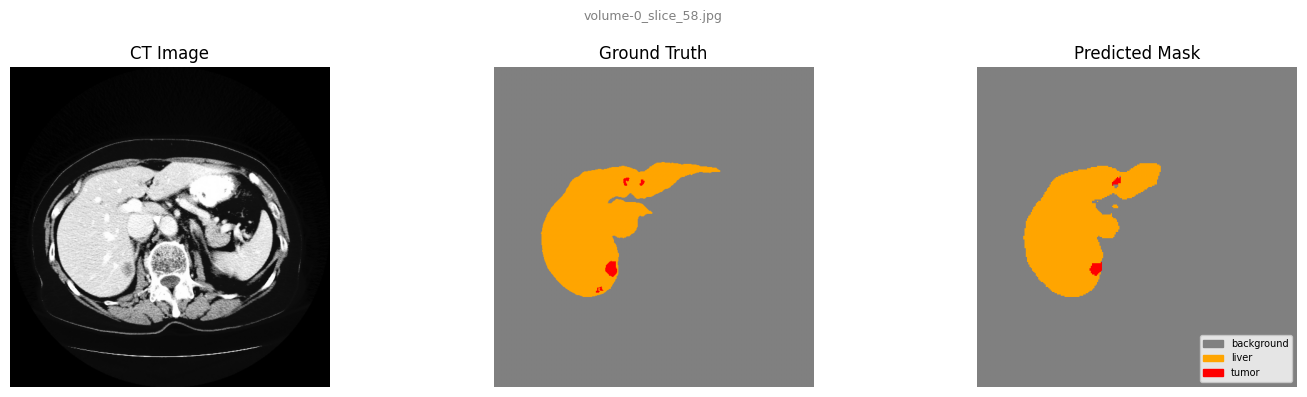

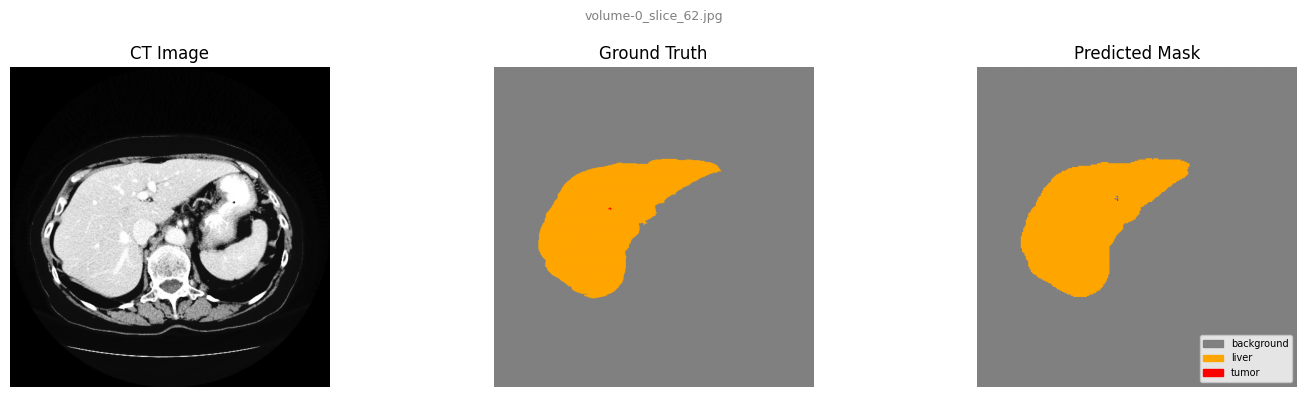

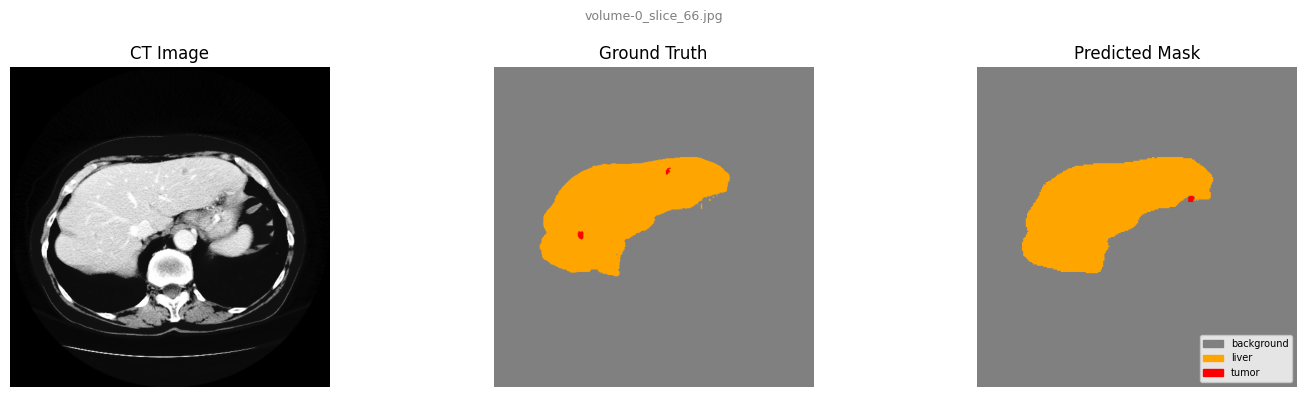

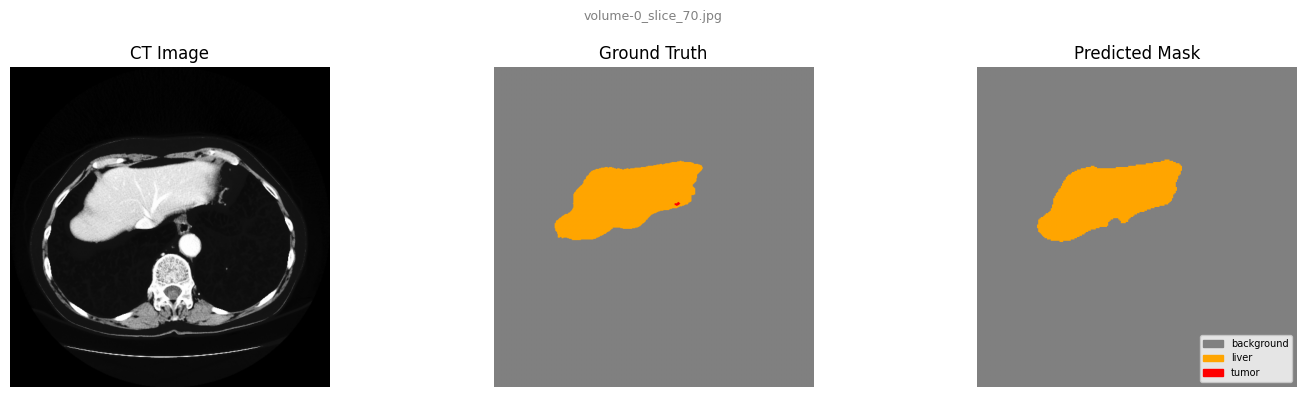

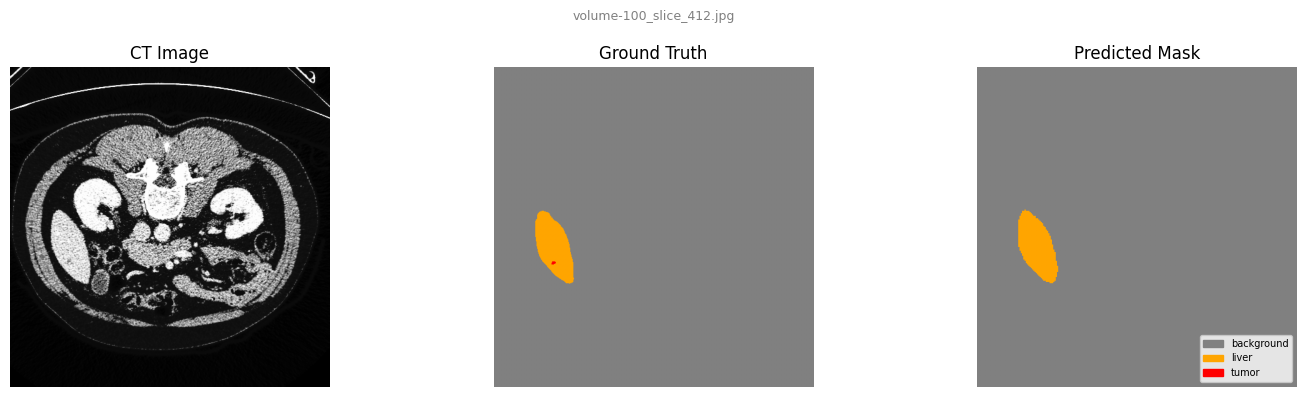

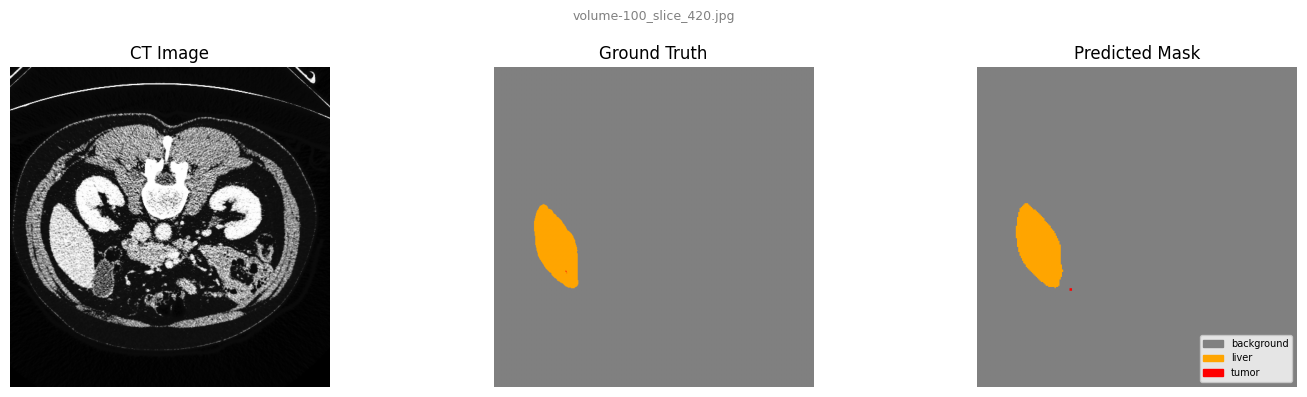

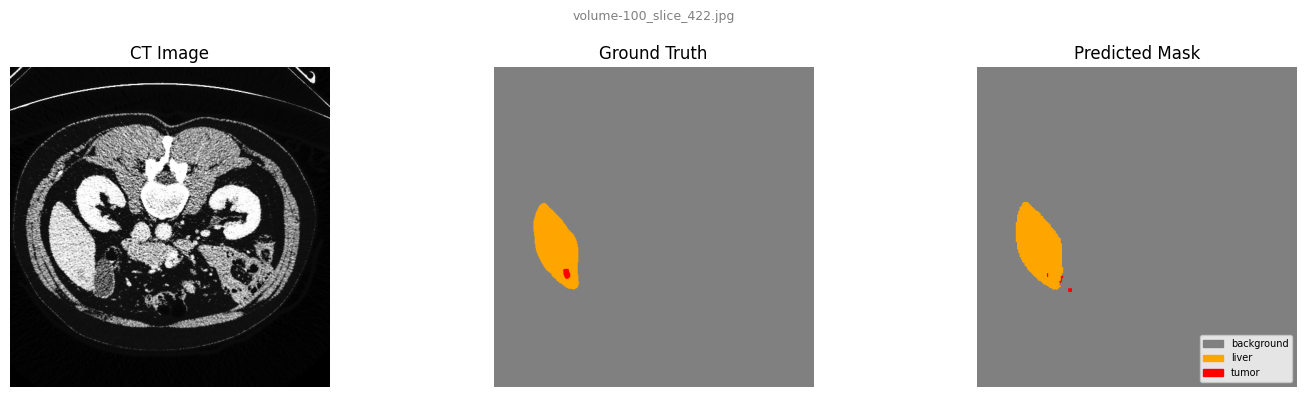

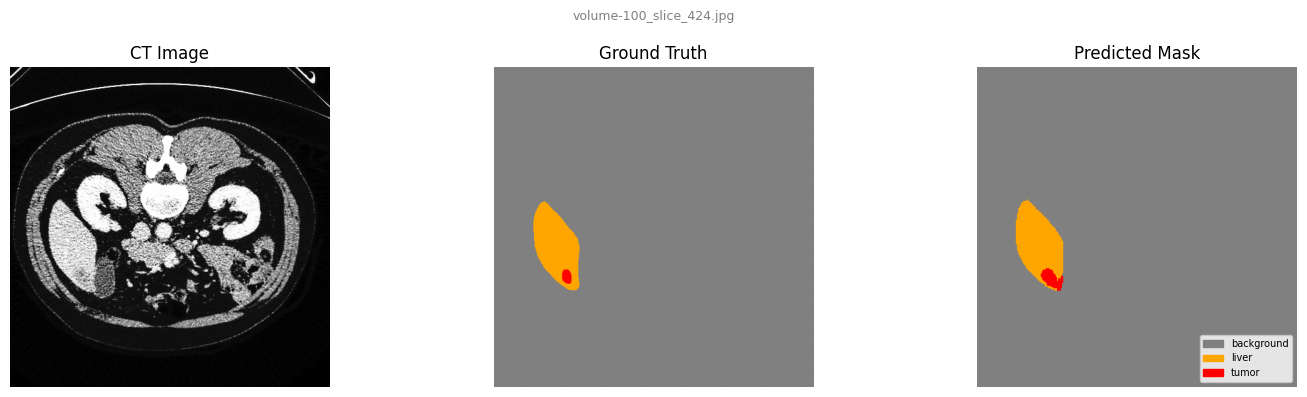

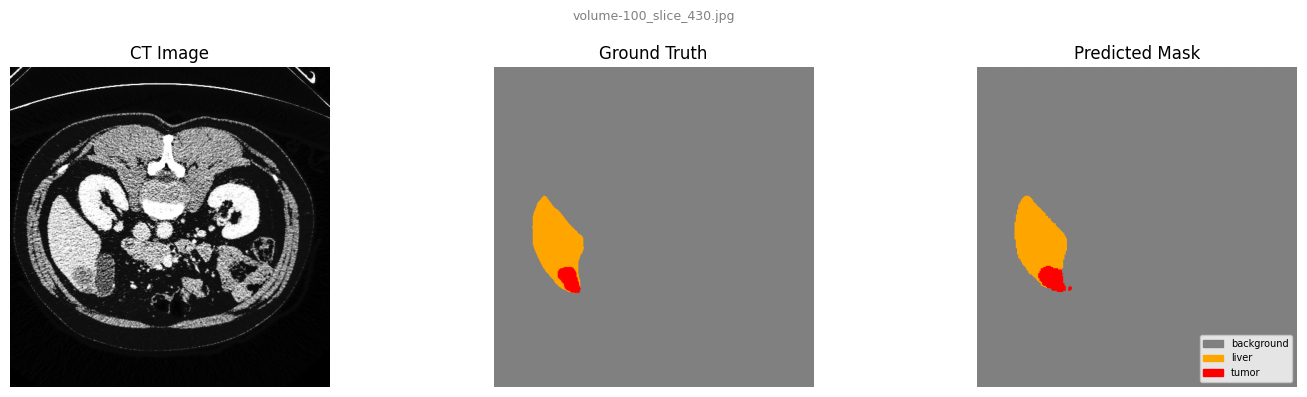

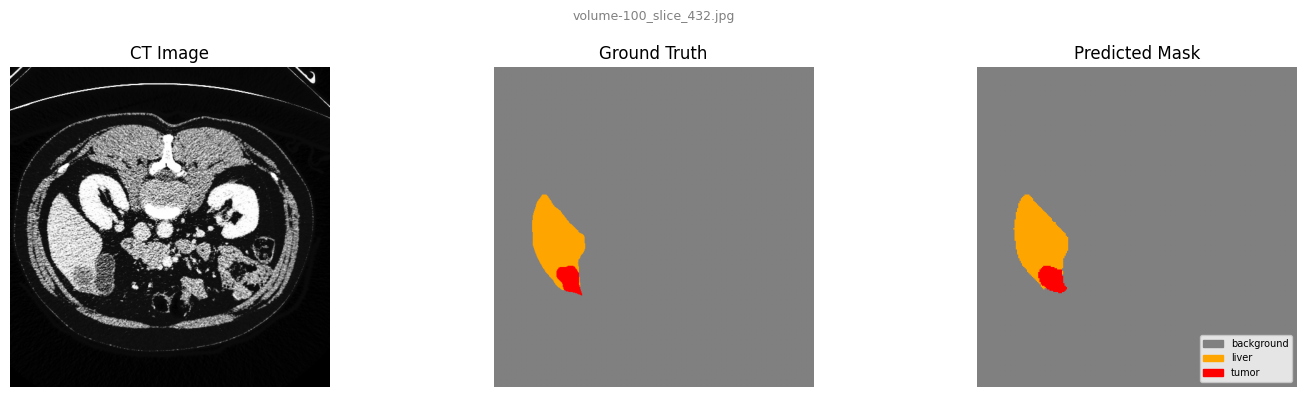

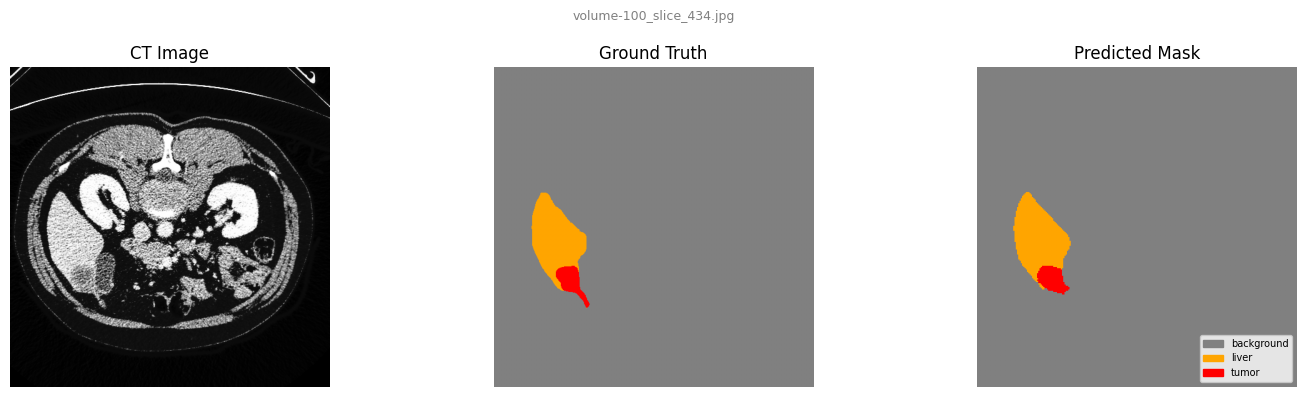

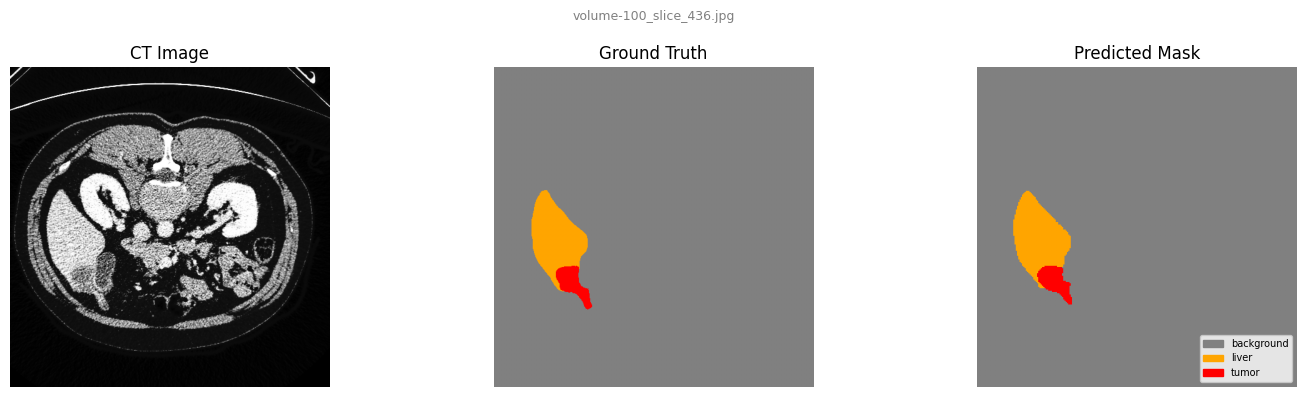

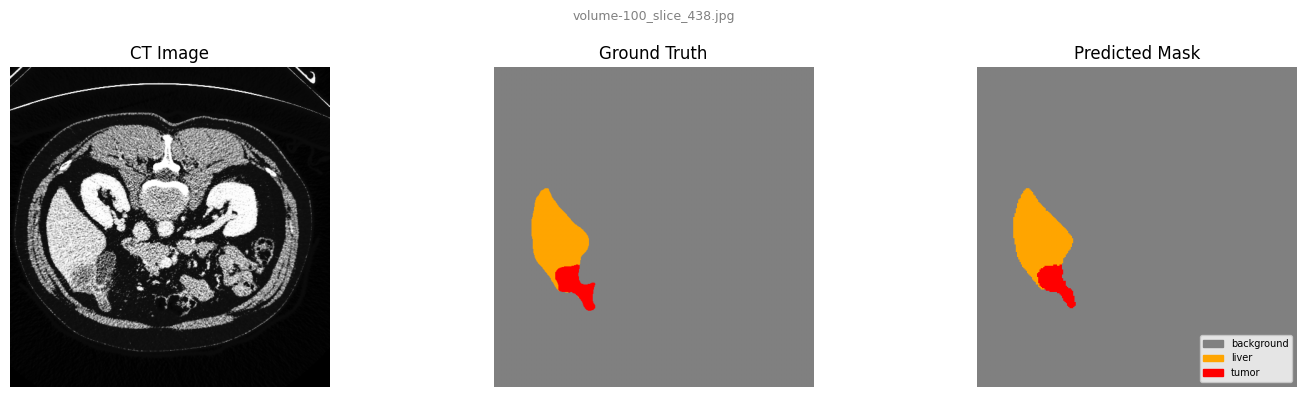

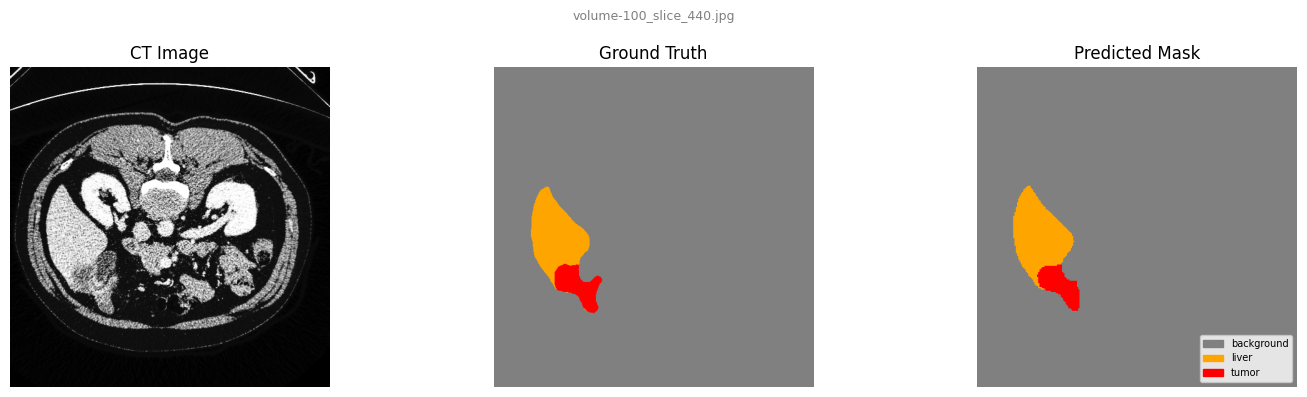

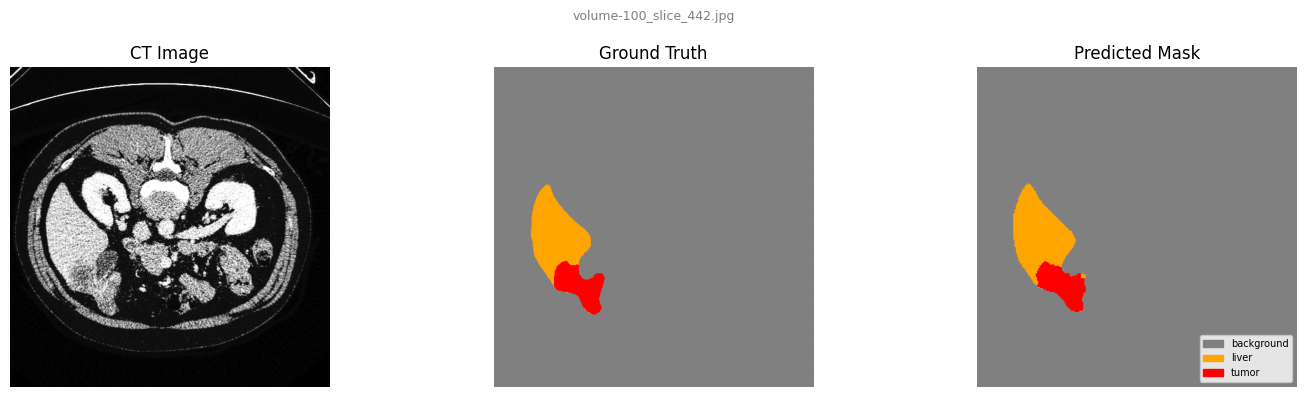

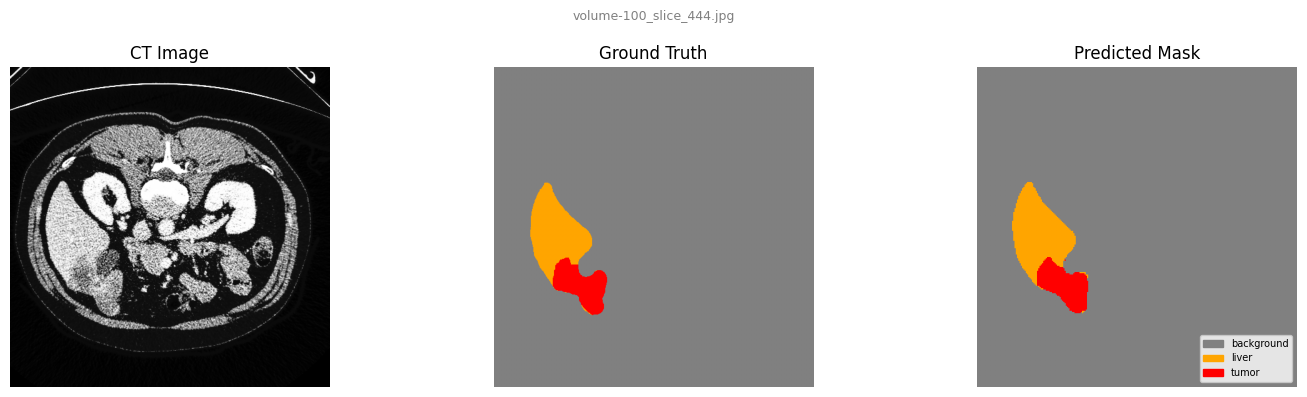

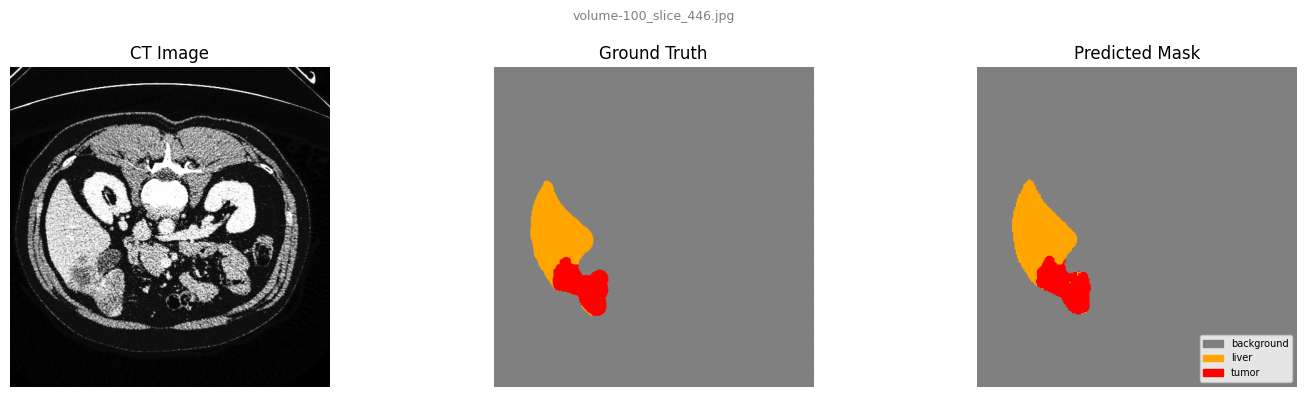

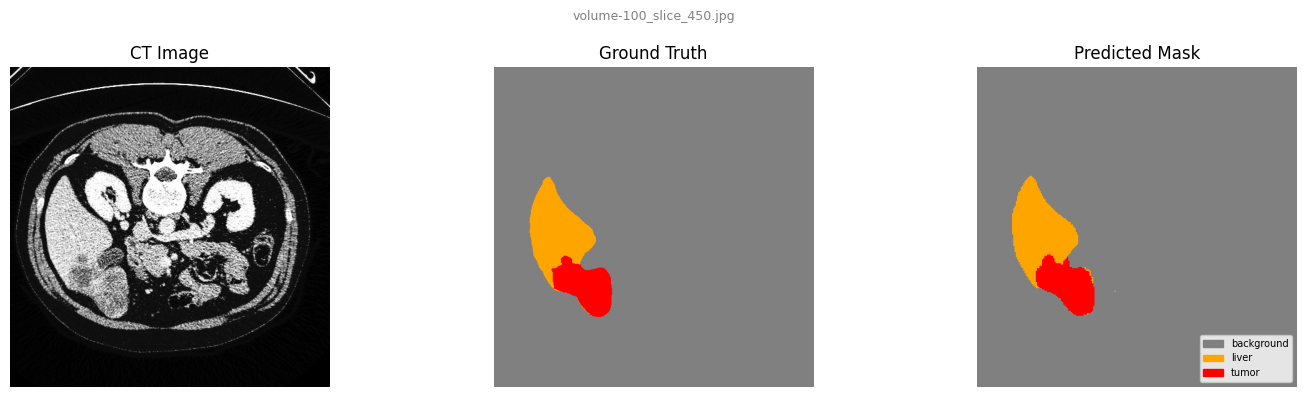

In [16]:
# Đảm bảo model + dls ở đúng device trước khi predict
learn.model.cuda()
learn.dls.to('cuda')

show_predictions(
    learn      = learn,
    image_paths= tumor_images,
    paths_cfg  = cfg.paths,
    n          = 20,
    data_cfg   = cfg.data,
)

---
## Cell 9 — (Optional) Load lại model từ file export

In [45]:
# Thay Cell 9 bằng cách này
from scripts.build_model import build_model
import torch

# 1. Tạo lại model với đúng config
model = build_model(cfg, load_pretrained=False, verbose=False)

# 2. Load weights từ best model (không phải .pkl)
weights_path = cfg.paths.best_model_path.with_suffix('.pth')
# hoặc nếu fastai lưu dạng khác:
state = torch.load(str(cfg.paths.output_dir / f"{cfg.paths.model_name}_best.pth"), 
                   map_location='cpu')
model.load_state_dict(state, strict=True)
model = model.cuda().eval()
print("Model loaded OK")

# 3. Rebuild learner từ dls gốc (đã có PILImageBW đúng)
from scripts.train import build_learner
learn_loaded = build_learner(cfg, dls, model)

Model loaded OK


---
## Cell 10 — Evaluation
> Đánh giá toàn diện trên tập validation. Chạy sau khi train xong.

In [46]:
# Chạy cell này trước show_predictions để debug
import torch
xb, yb = dls.one_batch()
print("DataLoader channels:", xb.shape)  # phải là [B, 1, 256, 256]

dummy = torch.randn(1, 1, 256, 256).cuda()
out = learn.model(dummy)
print("Model output:", out.shape)  # nếu crash ở đây → model expect 3 kênh

print("Model first conv weight shape:", 
      next(learn.model.parameters()).shape)  # phải là [64, 1, 3, 3]

DataLoader channels: torch.Size([8, 1, 256, 256])
Model output: torch.Size([1, 3, 256, 256])
Model first conv weight shape: torch.Size([64, 1, 3, 3])


In [49]:
import scripts.evaluate as ev
from PIL import Image as PILImg
from fastai.vision.all import PILImage
from pathlib import Path
import numpy as np
import torch

def _predict_single_fixed(learn, img_path: Path) -> np.ndarray:
    pil_gray = PILImg.open(img_path).convert("L")
    img = PILImage.create(pil_gray)
    with torch.no_grad():
        _, _, probs = learn.predict(img)
    return probs.argmax(dim=0).cpu().numpy().astype(np.int32)

# Monkey-patch vào module
ev._predict_single = _predict_single_fixed
print("✅ Đã patch _predict_single")

✅ Đã patch _predict_single



🚀 Đang sử dụng mô hình Learner đã có sẵn trong RAM.
   Device: cuda:0

Xác định tập đánh giá...
Dùng tập TEST: 2018 ảnh (/workspace/files/dataset/test/images)

Bắt đầu inference 2018 ảnh [TEST SET]...



/venv/main/lib/python3.12/site-packages/fastai/metrics.py:375: RuntimeWarning: Mean of empty slice
  return np.nanmean(binary_dice_scores)



══════════════════════════════════════════════════════════════════════════
  Evaluation Report [TEST SET]  —  In-Memory Model
  Images: 2018  |  Classes: 3  |  ['background', 'liver', 'tumor']
══════════════════════════════════════════════════════════════════════════
  Class              Dice   ±std       IoU   ±std  Precision   Recall     Support
  ────────────────────────────────────────────────────────────────────────
  background       0.9986 ±0.0032    0.9972 ±0.0063     0.9990   0.9982  516,629,886
  liver            0.8346 ±0.3431    0.8164 ±0.3422     0.8340   0.9721  11,676,275
  tumor            0.8611 ±0.3211    0.8485 ±0.3299     0.8800   0.9466     700,431
  ────────────────────────────────────────────────────────────────────────
  Foreground mDice             (excl. background): 0.8478
  Foreground mIoU              (excl. background): 0.8325

  Overall mDice                       : 0.8981  ±0.1549
  Overall mIoU                        : 0.8874  ±0.1592
  Pixel Accuracy 

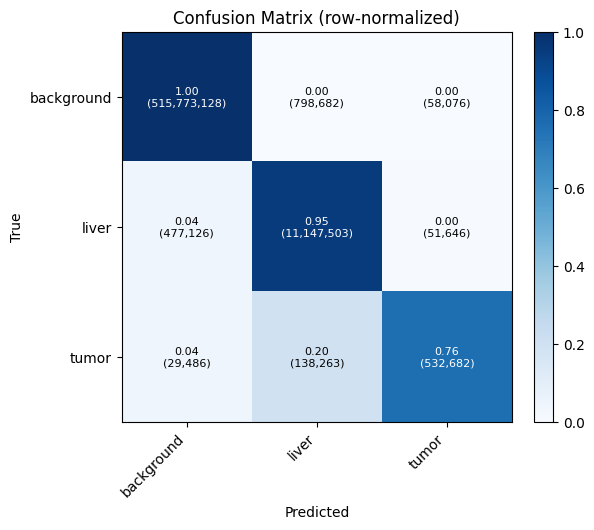


Dice distribution  → /workspace/files/outputs/unet_test_dice_distribution.png


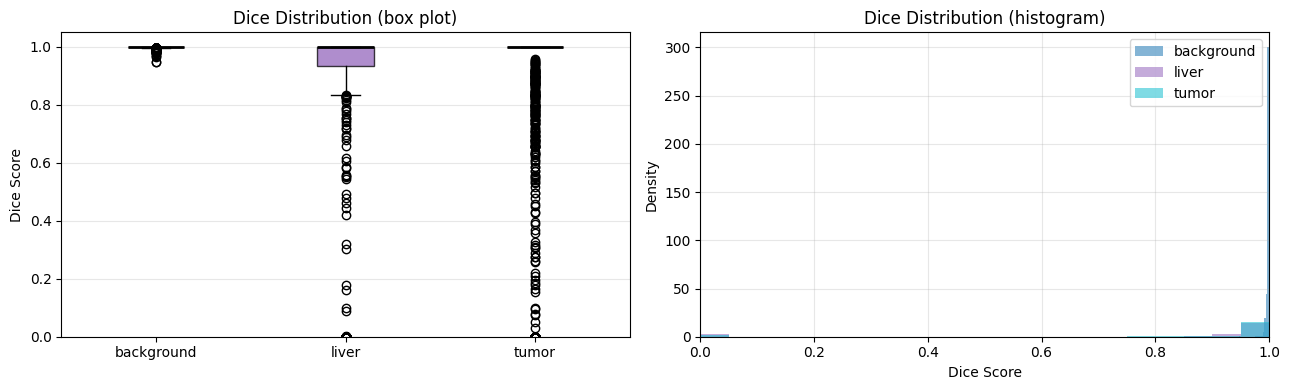


WORST cases       → /workspace/files/outputs/unet_test_cases_worst.png


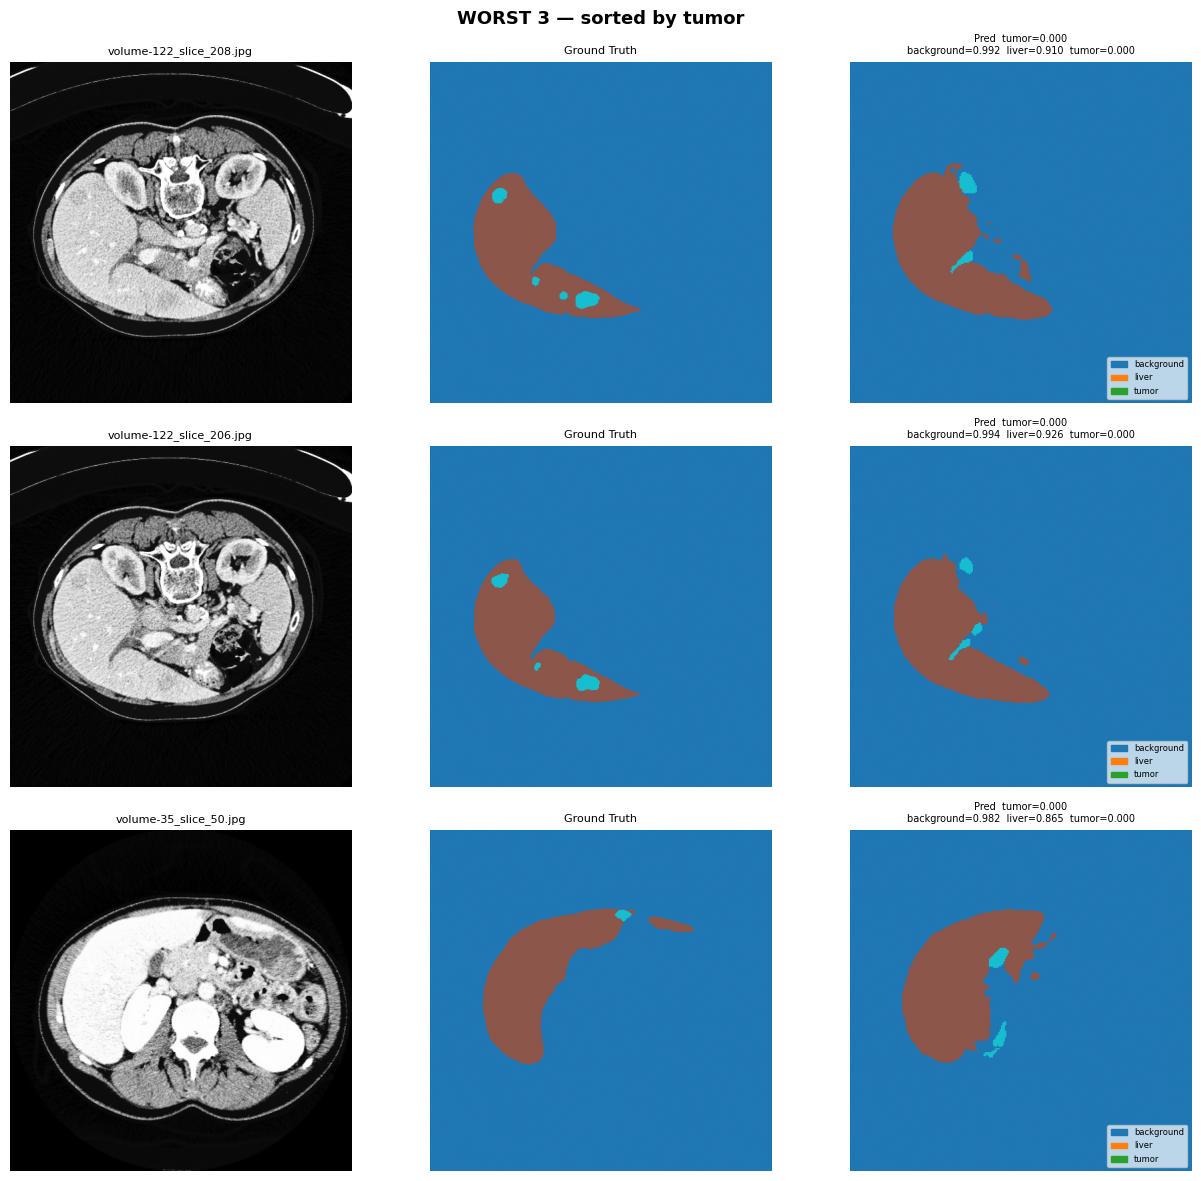

BEST cases       → /workspace/files/outputs/unet_test_cases_best.png


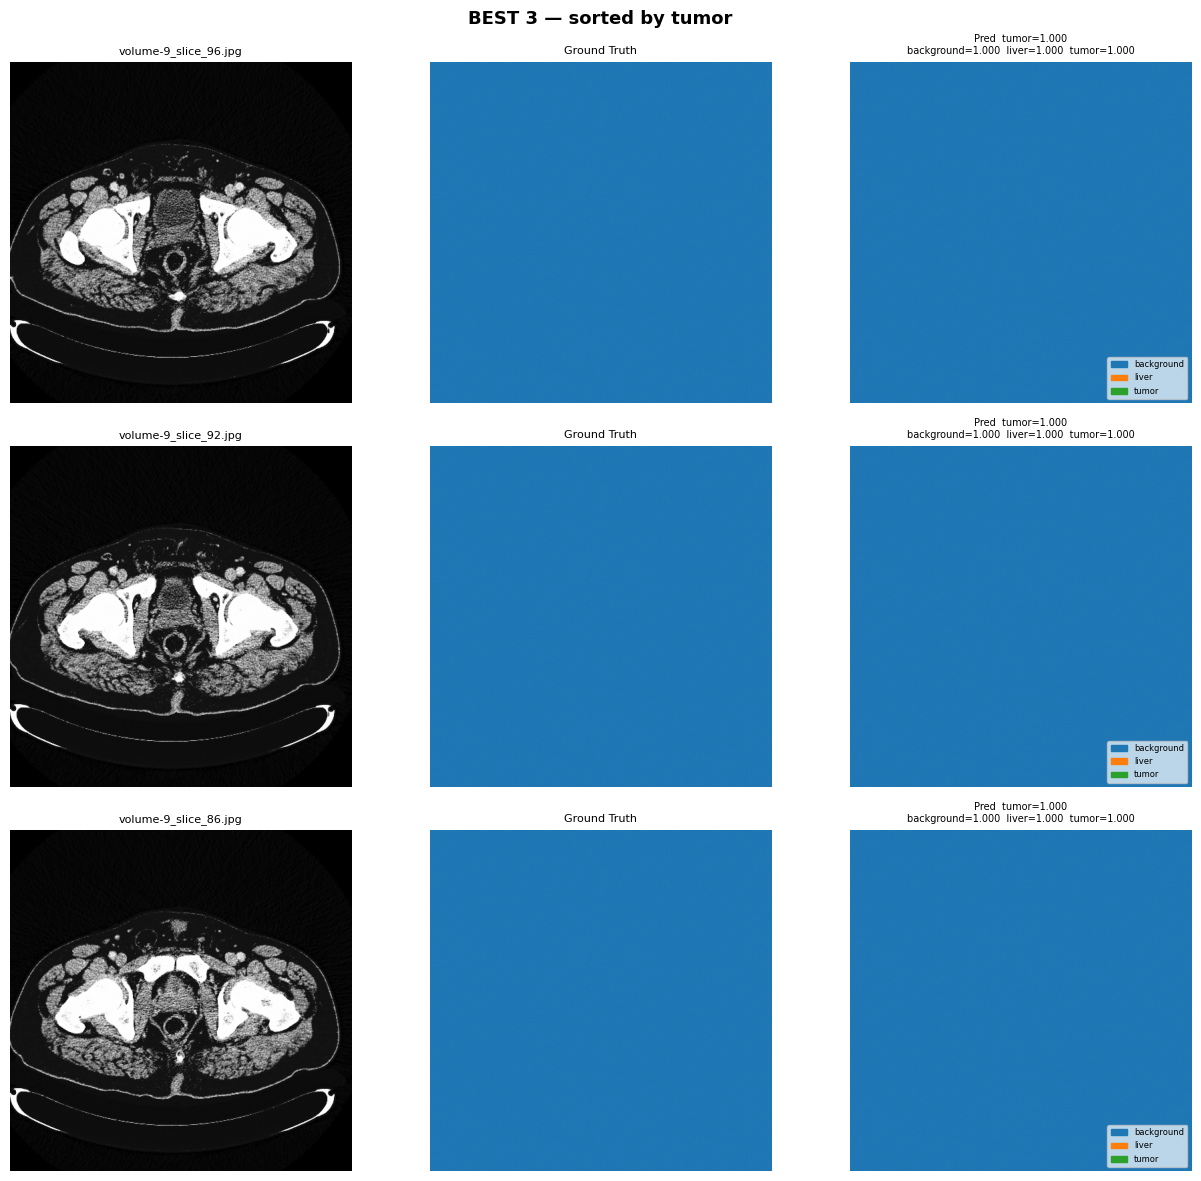

In [50]:
from scripts.evaluate import run_evaluation

results = run_evaluation(
    cfg           = cfg,
    learn         = learn_loaded,
    plot_cm       = True,
    plot_cases    = True,
    n_cases       = 3,
    sort_by_class = 'tumor',
)

---
## Cell 11 — So sánh V1 vs V2  *(Optional)*

In [ ]:
# Bỏ comment nếu muốn so sánh 2 model
# from scripts.evaluate import run_evaluation, compare_models
# from configs import Config, PathConfig
#
# # Eval V1
# cfg_v1 = Config(
#     paths=PathConfig(model_name='vmunetv1_liver', ...),
#     ...
# )
# results_v1 = run_evaluation(cfg_v1)
#
# # Eval V2 (đã có ở trên)
# results_v2 = results
#
# compare_models(
#     results_list  = [results_v1, results_v2],
#     model_labels  = ['VM-UNet V1', 'VM-UNet V2'],
#     out_path      = cfg.paths.output_dir / 'v1_vs_v2_comparison.png',
# )